<div align="center">

#  Week 5 – Unsupervised Learning

## Customer Segmentation using Clustering Algorithms

### 📘 Mall Customers Dataset

---

###  Objective

The objective of this project is to group customers into different clusters based on similar characteristics.

Unlike supervised learning, clustering works **without target labels**. It automatically discovers hidden patterns within the dataset.

During this project we will implement:

- ✅ K-Means Clustering
- ✅ Hierarchical (Agglomerative) Clustering

The performance of both algorithms will be analyzed and compared.

</div>

In [1]:
# Import required libraries

import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

print("Libraries imported successfully!")

Libraries imported successfully!


---

#  Step 1 – Load the Dataset

The Mall Customers dataset contains customer information including:

- Customer ID
- Gender
- Age
- Annual Income
- Spending Score

This data will be used to identify natural customer groups using clustering techniques.

In [2]:
# Load dataset

df = pd.read_csv("Mall_Customers.csv")

print("Dataset loaded successfully!")

Dataset loaded successfully!


In [3]:
# Load dataset

df = pd.read_csv("Mall_Customers.csv")

print("Dataset loaded!")

Dataset loaded!


In [4]:
df.head()

,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40


In [5]:
df.sample(5)

,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100)
155,156,Female,27,78,89
131,132,Male,39,71,75
175,176,Female,30,88,86
51,52,Male,33,42,60
169,170,Male,32,87,63


In [6]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 5 columns):
 #   Column                  Non-Null Count  Dtype
---  ------                  --------------  -----
 0   CustomerID              200 non-null    int64
 1   Gender                  200 non-null    str  
 2   Age                     200 non-null    int64
 3   Annual Income (k$)      200 non-null    int64
 4   Spending Score (1-100)  200 non-null    int64
dtypes: int64(4), str(1)
memory usage: 7.9 KB


In [7]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 5 columns):
 #   Column                  Non-Null Count  Dtype
---  ------                  --------------  -----
 0   CustomerID              200 non-null    int64
 1   Gender                  200 non-null    str  
 2   Age                     200 non-null    int64
 3   Annual Income (k$)      200 non-null    int64
 4   Spending Score (1-100)  200 non-null    int64
dtypes: int64(4), str(1)
memory usage: 7.9 KB


In [8]:
df.describe()

,CustomerID,Age,Annual Income (k$),Spending Score (1-100)
count,200.000000,200.000000,200.000000,200.000000
mean,100.500000,38.850000,60.560000,50.200000
std,57.879185,13.969007,26.264721,25.823522
min,1.000000,18.000000,15.000000,1.000000
25%,50.750000,28.750000,41.500000,34.750000
50%,100.500000,36.000000,61.500000,50.000000
75%,150.250000,49.000000,78.000000,73.000000
max,200.000000,70.000000,137.000000,99.000000


In [9]:
df.isnull().sum()

CustomerID                0
Gender                    0
Age                       0
Annual Income (k$)        0
Spending Score (1-100)    0
dtype: int64

# Select Features

For customer segmentation, we will use the following features:

- Annual Income (k$)
- Spending Score (1-100)

These two variables provide a clear representation of customer purchasing behavior.

In [10]:
# Select clustering features

X = df[["Annual Income (k$)", "Spending Score (1-100)"]]

X.head()

,Annual Income (k$),Spending Score (1-100)
0,15,39
1,15,81
2,16,6
3,16,77
4,17,40


# Customer Distribution

The scatter plot below visualizes customers according to their Annual Income and Spending Score.

This helps us identify whether natural groups appear before applying clustering algorithms.

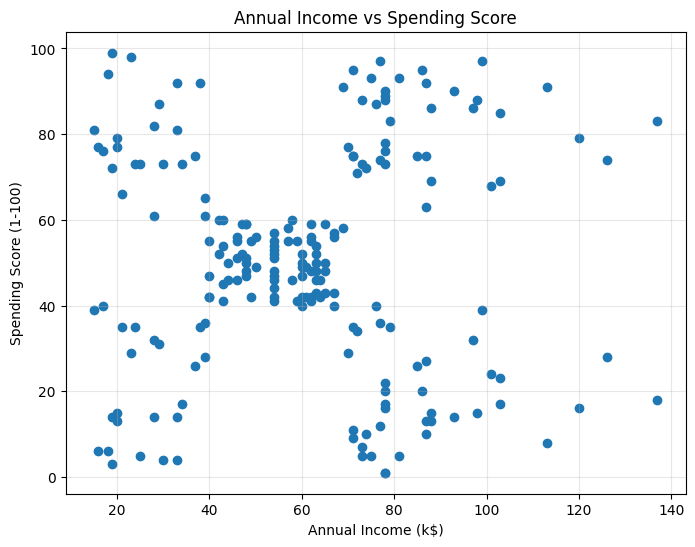

In [11]:
plt.figure(figsize=(8,6))

plt.scatter(
    X["Annual Income (k$)"],
    X["Spending Score (1-100)"]
)

plt.title("Annual Income vs Spending Score")

plt.xlabel("Annual Income (k$)")

plt.ylabel("Spending Score (1-100)")

plt.grid(alpha=0.3)

plt.savefig("Visualizations/income_vs_spending.png")

plt.show()